# Equipment Requests — Exploratory Data Analysis (EDA)

This notebook performs a structured exploratory analysis of Equipment Request data retrieved from the custom FastAPI service.  
The goal is to validate the shape, quality, and analytical usefulness of the dataset before building downstream pipelines (Fabric Lakehouse, Warehouse, Snowflake, or Power BI models).

---

## Objectives

- Retrieve normalized Equipment Request data from the API  
- Inspect schema, data types, and missing values  
- Explore key dimensions (requester, equipment type, approval stage, status)  
- Analyze cost patterns and distributions  
- Examine time‑based trends  
- Identify anomalies or data quality issues  
- Prepare insights for downstream modeling and ingestion

---

## Environment

This notebook assumes:
- The FastAPI service is running locally on `http://127.0.0.1:8000`
- The `/equipment-requests/` endpoint returns normalized JSON records
- Python is used for all analysis

In [2]:
# ---------------------------------------------------------
# Cell 2 — Setup: Imports and API Call
# ---------------------------------------------------------
# This cell:
# - Imports required Python libraries
# - Defines the API base URL
# - Retrieves equipment request data from the FastAPI service
# - Stores the results in a Python list for analysis
# ---------------------------------------------------------

import requests
import pandas as pd
from collections import Counter

BASE_URL = "http://127.0.0.1:8000"

# Call the API
resp = requests.get(f"{BASE_URL}/equipment-requests/")
resp.raise_for_status()

records = resp.json()
len(records), records[:2]

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /equipment-requests/ (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8000): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [2]:
# ---------------------------------------------------------
# Cell 3 — Convert API Records to DataFrame & Inspect Schema
# ---------------------------------------------------------
# This cell:
# - Converts the list of API records into a pandas DataFrame
# - Displays the first few rows for visual inspection
# - Shows column names, data types, and non-null counts
# ---------------------------------------------------------

df = pd.DataFrame(records)

df.head(), df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              16 non-null     str    
 1   approval_stage  16 non-null     int64  
 2   equipment_type  16 non-null     int64  
 3   estimated_cost  16 non-null     float64
 4   justification   16 non-null     str    
 5   quantity        16 non-null     int64  
 6   request_date    16 non-null     str    
 7   requested_by    16 non-null     str    
 8   status          16 non-null     int64  
 9   is_archived     16 non-null     bool   
 10  notes           11 non-null     str    
 11  new_column      0 non-null      object 
 12  created_on      16 non-null     str    
 13  modified_on     16 non-null     str    
 14  owner_id        16 non-null     str    
dtypes: bool(1), float64(1), int64(4), object(1), str(8)
memory usage: 5.1+ KB


(                                     id  approval_stage  equipment_type  \
 0  8df46aee-d30a-f111-8406-6045bd0a812b       519970002       519970002   
 1  73dddc50-d40a-f111-8406-6045bd0a812b       519970002       519970008   
 2  20871076-f10a-f111-8406-6045bd0a812b       519970001       519970002   
 3  2148889a-f10a-f111-8406-6045bd0a812b       519970001       519970002   
 4  ee5ae96f-f70a-f111-8406-6045bd0a812b       519970001       519970000   
 
    estimated_cost                              justification  quantity  \
 0            75.0           The HDMI port stopped working...         1   
 1          1000.0  Lamp for lighting during online meetings.         1   
 2            80.0                    Needed for new monitors         1   
 3            80.0                    needed for new monitors         1   
 4           799.0                   Onboarding new employee.         1   
 
   request_date                   requested_by     status  is_archived  \
 0   2026-02-16 

In [3]:
# ---------------------------------------------------------
# Cell 4 — Missing Values & Data Type Review
# ---------------------------------------------------------
# This cell:
# - Calculates missing value counts for each column
# - Computes missing value percentages
# - Displays data types for all columns
# - Helps identify fields that may need cleaning or conversion
# ---------------------------------------------------------

# Missing value counts
missing_counts = df.isna().sum()

# Missing value percentages
missing_pct = (df.isna().mean() * 100).round(2)

# Combine into a single DataFrame for readability
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct,
    "dtype": df.dtypes
})

missing_summary

,missing_count,missing_pct,dtype
id,0,0.00,str
approval_stage,0,0.00,int64
equipment_type,0,0.00,int64
estimated_cost,0,0.00,float64
justification,0,0.00,str
quantity,0,0.00,int64
request_date,0,0.00,str
requested_by,0,0.00,str
status,0,0.00,int64
is_archived,0,0.00,bool


In [4]:
# ---------------------------------------------------------
# Cell 5 — Key Dimensions Exploration
# ---------------------------------------------------------
# This cell explores the most important categorical fields:
# - requested_by: who is submitting requests
# - equipment_type: what type of equipment is being requested
# - approval_stage: where requests sit in the workflow
# - status: high-level request state
#
# These distributions help identify usage patterns, bottlenecks,
# and workflow behavior across the organization.
# ---------------------------------------------------------

dim_requested_by = df['requested_by'].value_counts(dropna=True)
dim_equipment_type = df['equipment_type'].value_counts(dropna=True)
dim_approval_stage = df['approval_stage'].value_counts(dropna=True)
dim_status = df['status'].value_counts(dropna=True)

dim_requested_by, dim_equipment_type, dim_approval_stage, dim_status

(requested_by
 mlloyd9@pods9.onmicrosoft.com    16
 Name: count, dtype: int64,
 equipment_type
 519970002    3
 519970001    3
 519970000    2
 519970005    2
 519970007    2
 519970008    1
 519970003    1
 519970004    1
 519970006    1
 Name: count, dtype: int64,
 approval_stage
 519970001    9
 519970002    6
 519970000    1
 Name: count, dtype: int64,
 status
 519970000    16
 Name: count, dtype: int64)

In [5]:
# ---------------------------------------------------------
# Cell 6 — Cost Analysis
# ---------------------------------------------------------
# This cell explores financial patterns in the dataset:
# - Total estimated cost across all requests
# - Cost by requester (who drives the most spend)
# - Cost by equipment type (which categories are expensive)
# - Basic distribution checks for potential outliers
#
# These metrics are foundational for budgeting, forecasting,
# and operational decision-making.
# ---------------------------------------------------------

# Total cost across all requests
total_cost = df['estimated_cost'].sum()

# Cost by requester
cost_by_requester = (
    df.groupby('requested_by')['estimated_cost']
      .sum()
      .sort_values(ascending=False)
)

# Cost by equipment type
cost_by_equipment_type = (
    df.groupby('equipment_type')['estimated_cost']
      .sum()
      .sort_values(ascending=False)
)

total_cost, cost_by_requester, cost_by_equipment_type

(np.float64(7503.0),
 requested_by
 mlloyd9@pods9.onmicrosoft.com    7503.0
 Name: estimated_cost, dtype: float64,
 equipment_type
 519970007    2498.0
 519970000    1598.0
 519970008    1000.0
 519970001     987.0
 519970006     699.0
 519970005     398.0
 519970002     235.0
 519970004      49.0
 519970003      39.0
 Name: estimated_cost, dtype: float64)

In [6]:
# ---------------------------------------------------------
# Cell 7 — Time‑Based Analysis
# ---------------------------------------------------------
# This cell explores temporal patterns in the dataset:
# - Converts request_date to a proper datetime type
# - Analyzes request volume by day and by month
# - Computes cost over time
# - Surfaces workflow seasonality or spikes
#
# Time-based analysis is essential for understanding trends,
# forecasting demand, and identifying operational bottlenecks.
# ---------------------------------------------------------

# Ensure request_date is a datetime type
df['request_date'] = pd.to_datetime(df['request_date'], errors='coerce')

# Requests per day
requests_per_day = (
    df.groupby(df['request_date'].dt.date)
      .size()
      .sort_index()
)

# Requests per month
requests_per_month = (
    df.groupby(df['request_date'].dt.to_period('M'))
      .size()
      .sort_index()
)

# Cost over time (daily)
cost_per_day = (
    df.groupby(df['request_date'].dt.date)['estimated_cost']
      .sum()
      .sort_index()
)

requests_per_day, requests_per_month, cost_per_day

(request_date
 2026-02-16    14
 2026-02-17     1
 2026-03-04     1
 dtype: int64,
 request_date
 2026-02    15
 2026-03     1
 Freq: M, dtype: int64,
 request_date
 2026-02-16    6515.0
 2026-02-17     189.0
 2026-03-04     799.0
 Name: estimated_cost, dtype: float64)

In [7]:
# ---------------------------------------------------------
# Cell 8 — Anomaly Detection
# ---------------------------------------------------------
# This cell identifies potential anomalies or data quality issues:
# - Requests with unusually high estimated cost
# - Requests with unusually high quantity
# - Requests missing justification text
# - Archived vs. active requests
#
# These checks help validate data integrity and surface patterns
# that may require business or workflow review.
# ---------------------------------------------------------

# High-cost requests (threshold can be adjusted)
high_cost = df[df['estimated_cost'] > df['estimated_cost'].quantile(0.95)]

# High-quantity requests (e.g., more than 5 units)
high_quantity = df[df['quantity'] > 5]

# Requests missing justification text
missing_justification = df[df['justification'].isna() | (df['justification'] == "")]

# Archived vs. active requests
archived_vs_active = df['is_archived'].value_counts(dropna=False)

high_cost, high_quantity, missing_justification, archived_vs_active

(                                     id  approval_stage  equipment_type  \
 9  36940c40-f90a-f111-8406-6045bd0a812b       519970002       519970007   
 
    estimated_cost justification  quantity request_date  \
 9          1499.0    Back pain.         1   2026-02-16   
 
                     requested_by     status  is_archived  \
 9  mlloyd9@pods9.onmicrosoft.com  519970000        False   
 
                            notes new_column            created_on  \
 9  Not allowable cost under CAS.       None  2026-02-16T05:35:16Z   
 
             modified_on                              owner_id  
 9  2026-02-16T05:43:08Z  203aa3b7-defe-f011-8406-000d3a306f55  ,
 Empty DataFrame
 Columns: [id, approval_stage, equipment_type, estimated_cost, justification, quantity, request_date, requested_by, status, is_archived, notes, new_column, created_on, modified_on, owner_id]
 Index: [],
 Empty DataFrame
 Columns: [id, approval_stage, equipment_type, estimated_cost, justification, quantity, requ

In [9]:
# ---------------------------------------------------------
# Install matplotlib for visualizations
# ---------------------------------------------------------
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 6.7 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 9.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.0 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 22.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------- ----------------- 3.9/7.0 MB 19.6 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 19.7 MB/s eta 0:0


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


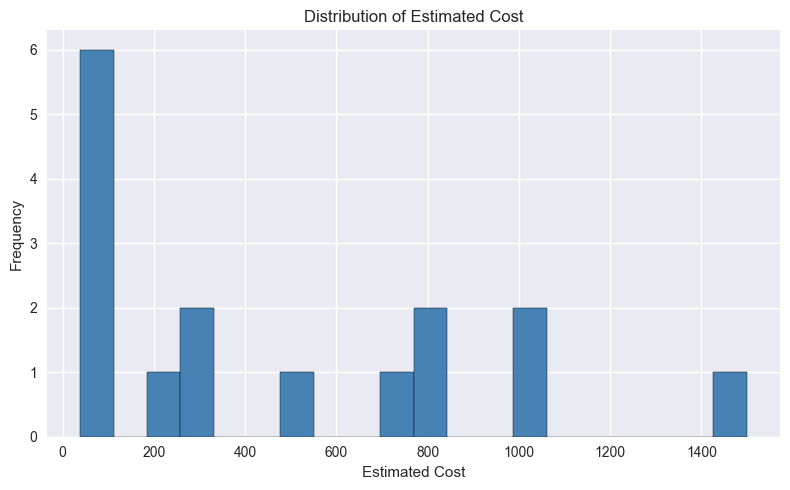

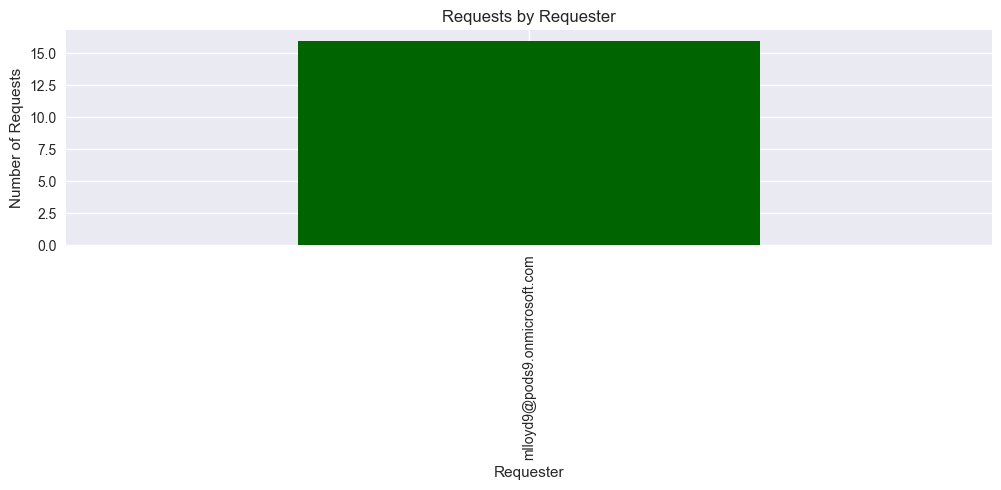

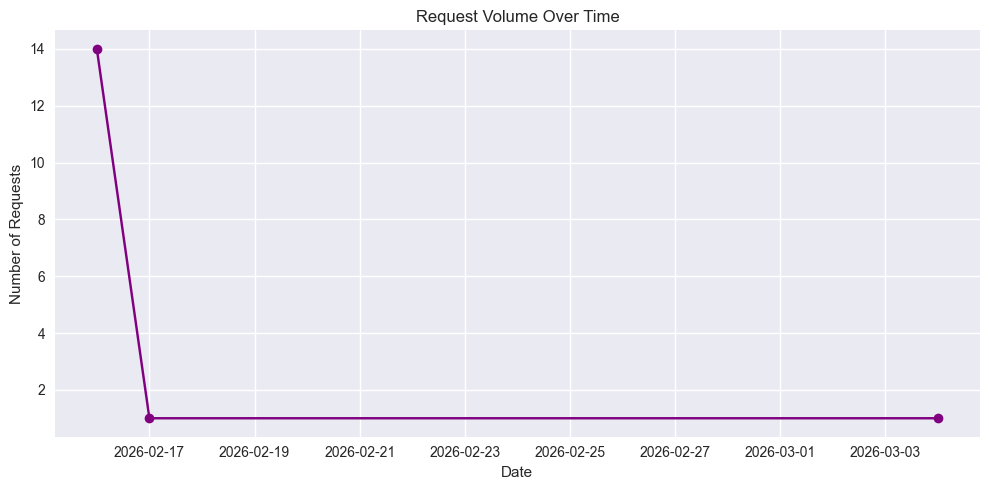

In [10]:
# ---------------------------------------------------------
# Cell 9 — Visualizations
# ---------------------------------------------------------
# This cell generates simple, high‑value visualizations:
# - Histogram of estimated cost (distribution of spend)
# - Bar chart of requests by requester
# - Line chart of request volume over time
#
# These visuals help validate data patterns and provide
# immediate insight into workflow behavior and cost trends.
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Use a clean style
plt.style.use("seaborn-v0_8")

# -----------------------------
# Histogram: Estimated Cost
# -----------------------------
plt.figure(figsize=(8,5))
df['estimated_cost'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title("Distribution of Estimated Cost")
plt.xlabel("Estimated Cost")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------------
# Bar Chart: Requests by Person
# -----------------------------
plt.figure(figsize=(10,5))
df['requested_by'].value_counts().plot(kind='bar', color='darkgreen')
plt.title("Requests by Requester")
plt.xlabel("Requester")
plt.ylabel("Number of Requests")
plt.tight_layout()
plt.show()

# -----------------------------
# Line Chart: Requests Over Time
# -----------------------------
requests_per_day = (
    df.groupby(df['request_date'].dt.date)
      .size()
      .sort_index()
)

plt.figure(figsize=(10,5))
requests_per_day.plot(kind='line', marker='o', color='purple')
plt.title("Request Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Requests")
plt.tight_layout()
plt.show()

In [11]:
# ---------------------------------------------------------
# Cell 10 — Choice Value Decoding
# ---------------------------------------------------------
# This cell maps Dataverse choice values (integers) to
# human-readable labels for easier analysis.
#
# These mappings come from the Dataverse table metadata.
# If new choice values are added later, update the dicts.
# ---------------------------------------------------------

# Equipment Type mapping
equipment_type_map = {
    519970000: "Laptop",
    519970001: "Monitor",
    519970002: "Docking Station",
    519970003: "Keyboard/Mouse",
    519970004: "Headset",
    519970005: "Webcam",
    519970006: "Office Chair",
    519970007: "Standing Desk",
    519970008: "Miscellaneous",
    # Add more if your Dataverse table includes them
}

# Approval Stage mapping
approval_stage_map = {
    519970000: "Requested",
    519970001: "Approved",
    519970002: "Denied",
}

# Status mapping
status_map = {
    519970000: "Submitted",
    519970001: "Approved",
    519970002: "Denied",
    519970003: "Fulfilled",
}

# Apply mappings
df['equipment_type_label'] = df['equipment_type'].map(equipment_type_map)
df['approval_stage_label'] = df['approval_stage'].map(approval_stage_map)
df['status_label'] = df['status'].map(status_map)

df[['equipment_type', 'equipment_type_label',
    'approval_stage', 'approval_stage_label',
    'status', 'status_label']].head()

,equipment_type,equipment_type_label,approval_stage,approval_stage_label,status,status_label
0,519970002,Docking Station,519970002,Denied,519970000,Submitted
1,519970008,Miscellaneous,519970002,Denied,519970000,Submitted
2,519970002,Docking Station,519970001,Approved,519970000,Submitted
3,519970002,Docking Station,519970001,Approved,519970000,Submitted
4,519970000,Laptop,519970001,Approved,519970000,Submitted


In [1]:
# ---------------------------------------------------------
# Cell 11 — Final Cleaned DataFrame (Analytics‑Ready)
# ---------------------------------------------------------
# This cell assembles the final, analysis-ready DataFrame.
# It includes:
# - Original normalized fields from the API
# - Human-readable labels for choice fields
# - Cleaned/converted data types (e.g., datetime)
#
# This DataFrame represents the "Gold" analytical layer
# and is suitable for downstream ingestion into:
# - Fabric Lakehouse (Delta)
# - Fabric Warehouse (SQL)
# - Snowflake
# - Power BI models
# ---------------------------------------------------------

final_df = df[[
    # Core identifiers
    'id',
    'requested_by',
    'request_date',
    'quantity',
    'estimated_cost',

    ## Choice values (raw)
    #'equipment_type',
    #'approval_stage',
    #'status',

    # Choice values (decoded labels)
    'equipment_type_label',
    'approval_stage_label',
    'status_label',

    # Additional fields
    'justification',
    'is_archived'
]].copy()

final_df.head(), final_df.info()

NameError: name 'df' is not defined

In [16]:
# ---------------------------------------------------------
# Cell 12 — Save / Export Options (Lakehouse, Parquet, SQL, Snowflake)
# ---------------------------------------------------------
# This cell provides OPTIONAL code patterns for exporting the
# final analytics-ready DataFrame to various destinations.
#
# Nothing runs by default — all export commands are commented out.
# Uncomment the section you want to use once you choose a landing zone.
#
# Supported patterns:
# - Fabric Lakehouse (Delta)
# - Parquet (local or cloud)
# - CSV (local or cloud)
# - Fabric Warehouse (SQL)
# - Snowflake
#
# These patterns allow you to turn this EDA notebook into a
# production ingestion pipeline with minimal changes.
# ---------------------------------------------------------

# =========================================================
# OPTION 1 — Fabric Lakehouse (Delta)
# =========================================================
# from pyspark.sql import SparkSession
# spark = SparkSession.builder.getOrCreate()
# spark_df = spark.createDataFrame(final_df)
# spark_df.write.format("delta").mode("overwrite").save("/lakehouse/default/equipment_requests")

# =========================================================
# OPTION 2 — Save as Parquet (local or cloud)
# =========================================================
# final_df.to_parquet("equipment_requests.parquet", index=False)

# =========================================================
# OPTION 3 — Save as CSV (local or cloud)
# =========================================================
final_df.to_csv("equipment_requests.csv", index=False)

# =========================================================
# OPTION 4 — Fabric Warehouse (SQL)
# =========================================================
# import sqlalchemy
# engine = sqlalchemy.create_engine("your_fabric_sql_connection_string")
# final_df.to_sql("equipment_requests", engine, if_exists="replace", index=False)

# =========================================================
# OPTION 5 — Snowflake
# =========================================================
# import snowflake.connector
# conn = snowflake.connector.connect(
#     user="YOUR_USER",
#     password="YOUR_PASSWORD",
#     account="YOUR_ACCOUNT"
# )
# write_cursor = conn.cursor()
# write_cursor.execute("USE DATABASE YOUR_DB")
# write_cursor.execute("USE SCHEMA YOUR_SCHEMA")
# final_df.to_sql("EQUIPMENT_REQUESTS", conn, if_exists="replace", index=False)

# ---------------------------------------------------------
# End of export patterns — choose one when ready.
# ---------------------------------------------------------

"Export patterns loaded. Uncomment your preferred destination when ready."

'Export patterns loaded. Uncomment your preferred destination when ready.'